# Bay Area Housing Affordability Project - Finny Bi (DIGHUM 101)

Project is divided into the following sections:
1. Data filtering and organization - from national Census ARS 5-year estimates (2024)

2. Income GINI and housing cost to income average calculations

3. County level housing price to income variance and its comparison across the Bay Area

4. Map of Bay Area counties housing cost to income average

5. Export Map as a shapefile 

See `README.md` for project objectives

## Setup

Imports modules including numpy, pandas for calculations; and matplotlib, geopandas, and display for mapping and visualizations.

Creates output paths for data calculations into tables, figures, maps, and gis presentations.

Accessing national Census data through API key provided by USCB. Filtering out Bay Area specific data through selecting targeted counties.

Imports two folders for shape file creation:
1. `tiger_cache/`  temporary storage for the TIGER/Line shapefiles the mapping downloads; geopandas needs an unzipped `.shp` on disk to read, so this is just where that raw external data lands.
2. `outputs/gis/`  the final shapefile that this project outputs


In [26]:
import io
import os
import zipfile

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display
import requests

# Initial styling for the plots
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["grid.alpha"] = 0.4
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True
#initial styling for the table 
pd.set_option("display.width", 140)


# Shapefile setups
TIGER_CACHE_DIR = os.path.join("data", "tiger_cache")  
GIS_DIR = os.path.join("outputs", "gis")                

# Setups to avoid python module failure
if not hasattr(pd.Series, "iteritems"):
    pd.Series.iteritems = pd.Series.items

import sys
try:
    import descartes  # noqa: F401
except ImportError:
    import types
    from matplotlib.patches import PathPatch
    from matplotlib.path import Path as MplPath

    def PolygonPatch(polygon, **kwargs):
        def ring_coords_and_codes(ring):
            coords = np.asarray(ring.coords)
            codes = np.full(len(coords), MplPath.LINETO, dtype=MplPath.code_type)
            codes[0] = MplPath.MOVETO
            return coords, codes

        rings = [polygon.exterior] + list(polygon.interiors)
        coords_codes = [ring_coords_and_codes(r) for r in rings]
        vertices = np.concatenate([cc[0] for cc in coords_codes])
        codes = np.concatenate([cc[1] for cc in coords_codes])
        return PathPatch(MplPath(vertices, codes), **kwargs)

    _descartes = types.ModuleType("descartes")
    _descartes_patch = types.ModuleType("descartes.patch")
    _descartes_patch.PolygonPatch = PolygonPatch
    _descartes.patch = _descartes_patch
    sys.modules["descartes"] = _descartes
    sys.modules["descartes.patch"] = _descartes_patch

import shapely.geometry.base as _shapely_base
if not hasattr(_shapely_base.BaseMultipartGeometry, "__iter__"):
    _shapely_base.BaseMultipartGeometry.__iter__ = lambda self: iter(self.geoms)

for _idx_name in ("Int64Index", "UInt64Index", "Float64Index"):
    if not hasattr(pd, _idx_name):
        setattr(pd, _idx_name, pd.Index)

# A realistic browser user agent to override cloudfare verification
HTTP_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "*/*",
    "Accept-Language": "en-US,en;q=0.9",
}

# print("Pass")

## Data Filtering and Organization

Selecting: California state, 9 counties in the Bay Area

Data needed for calculations:
1. Median household income 

2. Median home value 

3. Median gross rent

4. Renter cost burden distribution 

5. Owner cost burden distribution

,county_name,mean_household_income,mean_home_value,mean_gross_rent,GEOID
0,Alameda,137273.250667,1.082685e+06,2532.439353,379
1,Contra Costa,138893.041667,9.515337e+05,2606.406780,242
2,Marin,155614.311475,1.440687e+06,2789.593220,63
3,Napa,118494.487179,9.960579e+05,2332.594595,40
4,San Francisco,146049.675214,1.426979e+06,2541.160338,244
5,San Mateo,168773.598837,1.498687e+06,2981.733728,174
6,Santa Clara,167168.051471,1.410021e+06,2898.222772,408
7,Solano,103235.367347,6.101000e+05,2285.540816,100
8,Sonoma,110257.165289,8.541512e+05,2209.610169,122


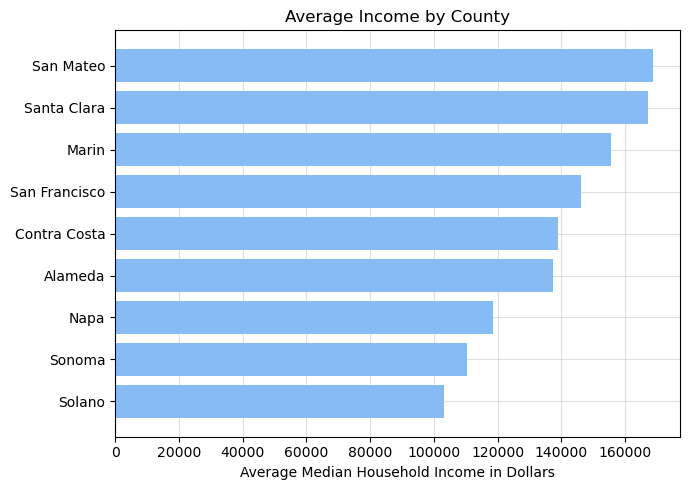

In [27]:

#Select state and county filters within the census data
STATE_FIPS = "06" 
BAY_AREA = {
    "Alameda": "001", 
    "Contra Costa": "013", 
    "Marin": "041", 
    "Napa": "055",
    "San Francisco": "075", 
    "San Mateo": "081", 
    "Santa Clara": "085",
    "Solano": "095", 
    "Sonoma": "097",
} 

ACS_SELECTION = {
    "B19013_001E": "median_household_income",
    "B25077_001E": "median_home_value",
    "B25064_001E": "median_gross_rent",
    "B25070_001E": "burden_total",
    "B25091_002E": "own_mort_total",
    "B25091_013E": "own_nomort_total",
}

# Combine with mortgage and without mortgage data into owner burden total
owner_burden_total = {"owner_burden_total": ("own_mort_total", "own_nomort_total")}


#Accessing census data through the offical government website with my API key
def fetch_county_data(county_fips, county_name):
    census_api_key = os.environ.get("CENSUS_API_KEY", "7d98964c6a13c0098df0fef0c2afb60246ad08ac")
    var_codes = ",".join(ACS_SELECTION.keys())
    ACS_5 = "acs/acs5"
    url = (
        f"https://api.census.gov/data/{2024}/{ACS_5}"
        f"?get=NAME,{var_codes}&for=tract:*"
        f"&in=state:{STATE_FIPS}+county:{county_fips}&key={census_api_key}"
    )
    response = requests.get(url, headers=HTTP_HEADERS, timeout=60)
    response.raise_for_status()
    data = response.json()
    header, rows = data[0], data[1:]
    df = pd.DataFrame(rows, columns=header)
    df["county_name"] = county_name
    return df

#Creating new output table from filtered data
def filter_census_data():
    all_counties = [
        fetch_county_data(fips, name) for name, fips in BAY_AREA.items()
    ]
    bay_area = pd.concat(all_counties, ignore_index=True)
    bay_area = bay_area.rename(columns=ACS_SELECTION)
    bay_area["GEOID"] = bay_area["state"] + bay_area["county"] + bay_area["tract"]

    for col in ACS_SELECTION.values():
        bay_area[col] = pd.to_numeric(bay_area[col], errors="coerce")
        bay_area.loc[bay_area[col] < 0, col] = pd.NA

    # Combine owner "with mortgage" + "without mortgage" into single brackets
    for combined_col, (mort_col, nomort_col) in owner_burden_total.items():
        bay_area[combined_col] = bay_area[mort_col].fillna(0) + bay_area[nomort_col].fillna(0)

    raw_owner_cols = list(sum(owner_burden_total.values(), ()))
    bay_area = bay_area.drop(columns=raw_owner_cols)

    return bay_area

acs_df = filter_census_data()

# Group by county 
county_table = acs_df.groupby("county_name", as_index=False).agg(
    mean_household_income=("median_household_income", "mean"),
    mean_home_value=("median_home_value", "mean"),
    mean_gross_rent=("median_gross_rent", "mean"),
    GEOID=("GEOID", "count"),
)
display(county_table)

#Visualization chart: sorting counties by their average income (descending)
county_avg_income = (acs_df.groupby("county_name")["median_household_income"].mean().sort_values())

fig, plot_avg = plt.subplots(figsize=(7,5))
plot_avg.barh(county_avg_income.index, county_avg_income.values, color="#86bbf3")
plot_avg.set_title("Average Income by County")
plot_avg.set_xlabel("Average Median Household Income in Dollars")
plt.tight_layout()
plt.show()

#print("Pass")

## Income GINI and Housing Cost to Income Average Calculations

Using concentrated data from the previous cell, caculates:
1. Income GINI coefficient (average per county) - the standard Gini coefficient of median household
   income across each county's tracts

2. Housing price to income ratio (average per county) — median home value ÷
   median household income


In [28]:
#Calculate income GINI coefficient for each county
def get_gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    index = np.arange(1, n + 1)
    return float((2 * np.sum(index * x)) / (n * np.sum(x)) - (n + 1) / n)


#Calculate housing price to income using the data frame created in the previous cell
def county_calculations(acs_df):
    df = acs_df.copy()
    df["price_to_income"] = df["median_home_value"] / df["median_household_income"]

    county_track = (
        df.groupby("county_name").agg(
            mean_income=("median_household_income", "mean"),
            income_gini=("median_household_income", get_gini),
            mean_price_to_income=("price_to_income", "mean"),
            GEOID=("GEOID", "count"),
        ).reset_index().sort_values("mean_price_to_income", ascending=False)
    )

    return df, county_track


ratio_df, county_track = county_calculations(acs_df)

print("County GINI and price to income average, sorted descending:")
display(county_track)

#print("Pass")


County GINI and price to income average, sorted descending:


,county_name,mean_income,income_gini,mean_price_to_income,GEOID
4,San Francisco,146049.675214,0.227542,10.936491,244
2,Marin,155614.311475,0.203501,9.941935,63
5,San Mateo,168773.598837,0.172547,9.189751,174
6,Santa Clara,167168.051471,0.188667,8.725732,408
0,Alameda,137273.250667,0.235160,8.529489,379
3,Napa,118494.487179,0.140650,8.427899,40
8,Sonoma,110257.165289,0.142411,7.862144,122
1,Contra Costa,138893.041667,0.220420,6.838921,242
7,Solano,103235.367347,0.172653,6.165321,100


## County Level Housing Price to Income Variance and Its Comparison Across the Bay Area

Examining housing affordability - measuring the variance of housing price to income level ratio within and across counties in the Bay Area:

1. Calculate the variance of housing price to income within each county, displaying histograms for each county, shows the distribution of housing affords within each county

2. Compare housing price to income variance across all counties using box plot


Housing price to income variance by county, sorted descending:


,county_name,price_to_income_variance
0,San Francisco,55.592170
1,Marin,14.023093
2,Alameda,11.646193
3,Santa Clara,7.759191
4,Napa,6.430649
5,San Mateo,5.204807
6,Sonoma,4.404544
7,Contra Costa,2.393051
8,Solano,2.071183


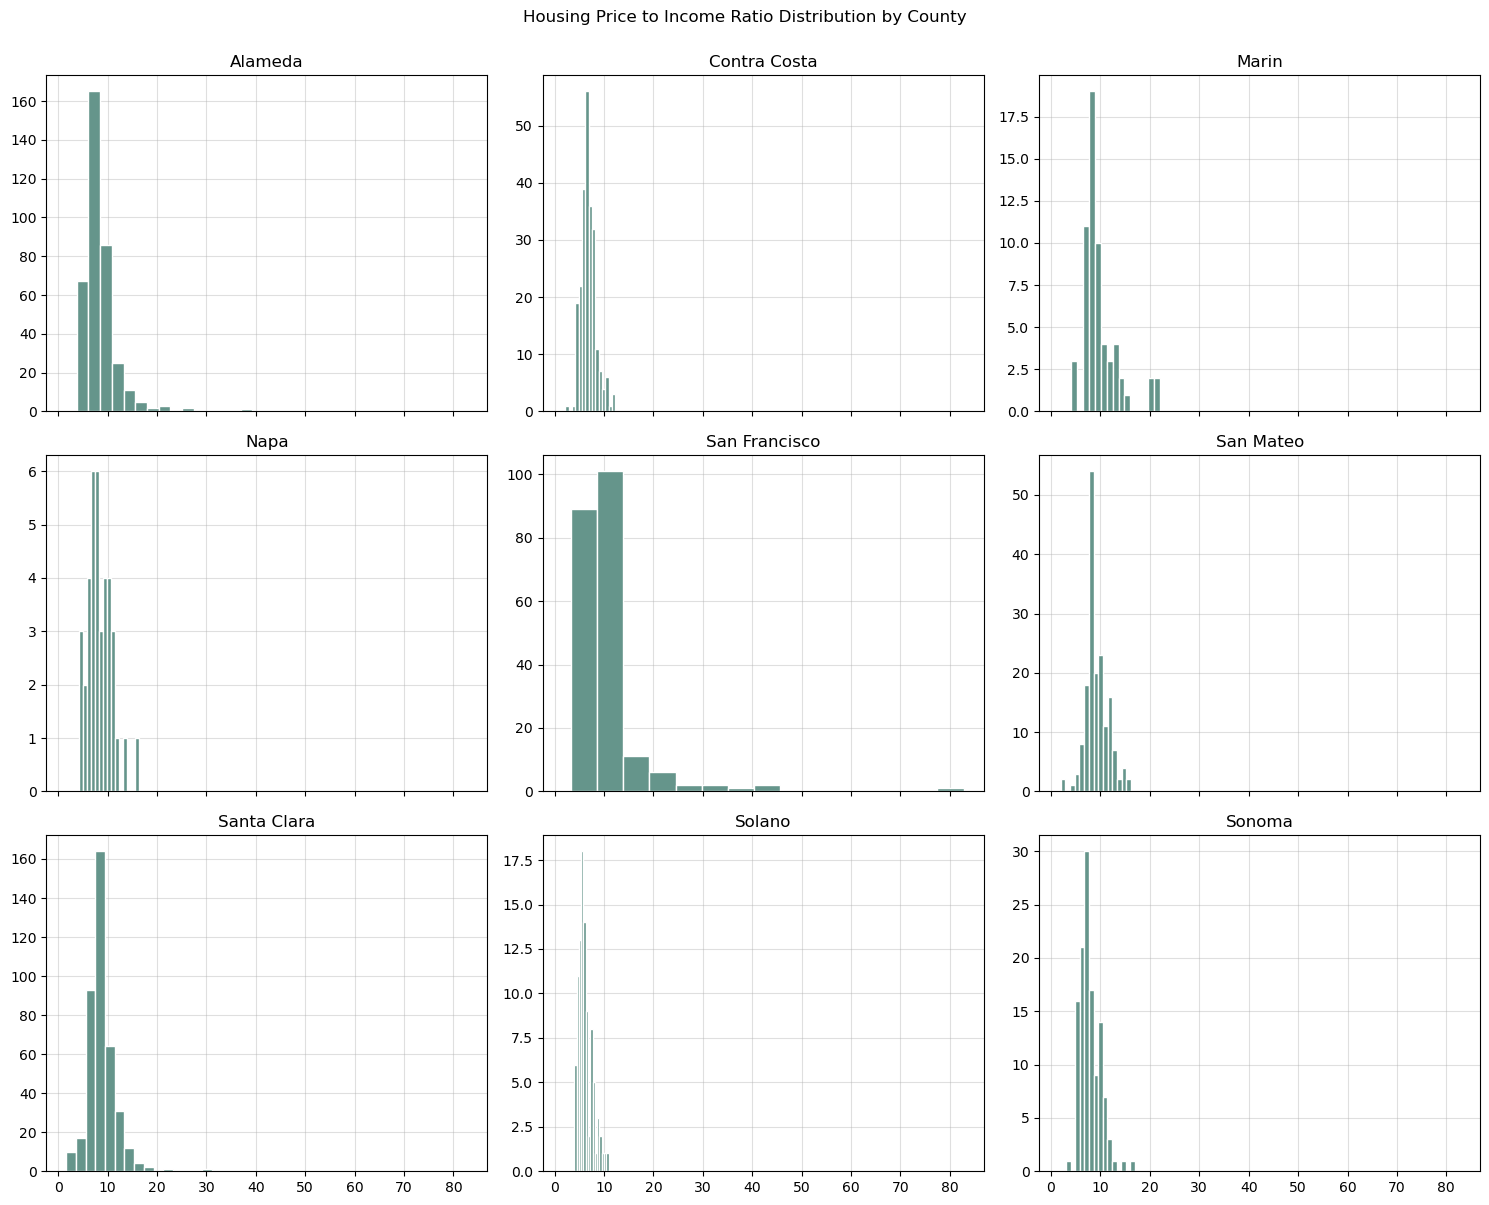

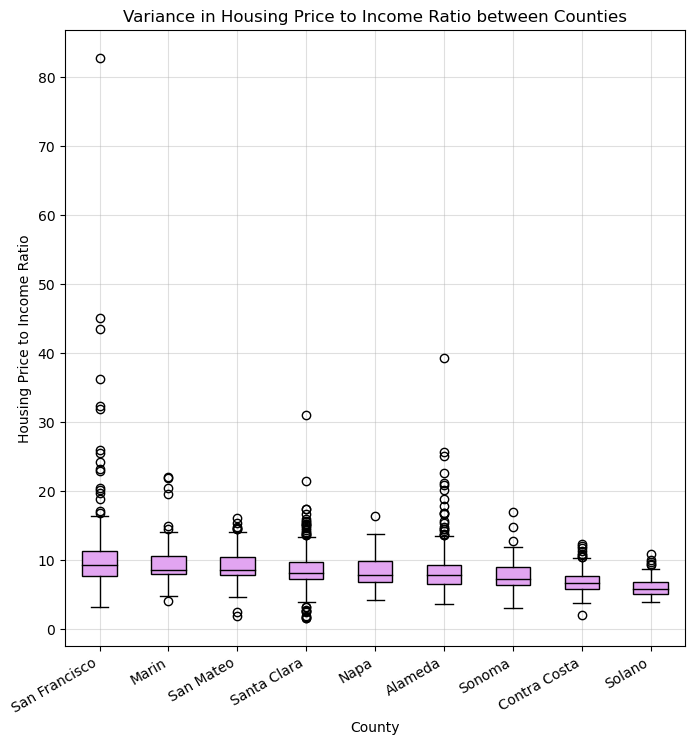

In [24]:
def visualizations(ratio_df):
    df = ratio_df

    price_to_income_variance = (df.groupby("county_name")["price_to_income"].var().sort_values(ascending=False)
        .rename("price_to_income_variance").reset_index())
    print("Housing price to income variance by county, sorted descending:")
    display(price_to_income_variance)

    # 1. County-wise housing price to income - Histogram
    counties = df["county_name"].dropna().unique()
    #Set grid
    n = len(counties)
    n_col = 3
    n_row = -(-n // n_col)
    fig, axes = plt.subplots(n_row, n_col, figsize=(15, 4 * n_col), sharex=True)
    axes = axes.flatten()

    for i, county in enumerate(sorted(counties)):
        subset = df[df["county_name"] == county]["price_to_income"].dropna()
        axes[i].hist(subset, bins=15, color="#65958b", edgecolor="white")
        axes[i].set_title(county)
        axes[i].set_xlabel("")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    fig.suptitle("Housing Price to Income Ratio Distribution by County", y=1)
    fig.tight_layout()
    plt.show()


    # 2. Comparing the spread of housing price to income variation by county - Boxplot
    order = df.groupby("county_name")["price_to_income"].median().sort_values(ascending=False).index
    grouped_data = [df.loc[df["county_name"] == county, "price_to_income"].dropna() for county in order]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.boxplot(grouped_data, labels=list(order), patch_artist=True,
                boxprops=dict(facecolor="#e2a5f1"), medianprops=dict(color="#000000"))
    ax.set_xlabel("County")
    ax.set_ylabel("Housing Price to Income Ratio")
    ax.set_title("Variance in Housing Price to Income Ratio between Counties")
    plt.xticks(rotation=30, ha="right")
    plt.show()

    return price_to_income_variance

price_to_income_variance = visualizations(ratio_df)

#print("Pass")


## Map of Bay Area Counties Housing Cost to Income Average

Maps out a graduated colors map of Bay Area housing price to income average, the darkest area is shown to be having the highest ratio of housing price to income, which means the least housing afforability.


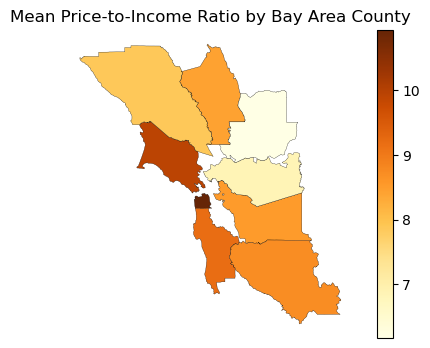

In [29]:

TRACT_SHP_URL = f"https://www2.census.gov/geo/tiger/TIGER{2024}/TRACT/tl_{2024}_{STATE_FIPS}_tract.zip"

BAY_AREA_FIPS = {v: k for k, v in BAY_AREA.items()}  

def download_and_extract(url, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)
    try:
        r = requests.get(url, headers=HTTP_HEADERS, timeout=120)
        r.raise_for_status()
    except requests.exceptions.HTTPError as e:
        raise RuntimeError(
            f"Failed to download {url} ({e}). This URL is occasionally blocked by "
            "Census's Cloudflare protection even with browser headers. Try re-running "
            "this cell once, or download the file manually from "
            f"{url.rsplit('/', 1)[0]}/ and extract it into {dest_dir}."
        ) from e
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(dest_dir)


def load_shapefile(dest_dir):
    shp_file = [f for f in os.listdir(dest_dir) if f.endswith(".shp")][0]
    return gpd.read_file(os.path.join(dest_dir, shp_file))


def county_map(county_track):
    tract_dir = os.path.join(TIGER_CACHE_DIR, "tracts")

    if not os.path.exists(tract_dir):
        print("[Step 6] Downloading tract shapefile...")
        download_and_extract(TRACT_SHP_URL, tract_dir)

    tracts = load_shapefile(tract_dir)
    tracts = tracts[tracts["COUNTYFP"].isin(BAY_AREA_FIPS.keys())].copy()
    tracts["county_name"] = tracts["COUNTYFP"].map(BAY_AREA_FIPS)

    # Fixing the shape of the map of Bay Area
    if {"ALAND", "AWATER"}.issubset(tracts.columns):
        tracts = tracts[tracts["ALAND"] > tracts["AWATER"]]

    map_gdf = tracts.dissolve(by="county_name")[["geometry"]].reset_index()
    map_gdf = map_gdf.merge(county_track, on="county_name", how="left")

    fig, ax = plt.subplots(figsize=(6, 4))
    map_gdf.plot(
        column="mean_price_to_income",
        cmap="YlOrBr",
        legend=True,
        edgecolor="Black", linewidth=0.2,
        ax=ax,
    )
    ax.set_title("Mean Price-to-Income Ratio by Bay Area County")
    ax.axis("off")
    plt.show()

    return map_gdf

map_gdf = county_map(county_track)

#print("Pass")


## Export Map as a Shapefile

To actually extract this file from this project and to use this mapped data in mapping applications such as ArcGIS Pro, a shape file must be exported. 

This step is the exportation of the shapefile of the map created through the previous cell.

In [22]:
SHAPEFILE_RENAME_MAP = {
    "county_name": "county",
    "mean_income": "avg_income",
    "income_gini": "gini",
    "mean_price_to_income": "price_to_income",
}

def export(map_gdf):
    gdf = map_gdf.copy()
    os.makedirs(GIS_DIR, exist_ok=True)

    shp_gdf = gdf.rename(columns={k: v for k, v in SHAPEFILE_RENAME_MAP.items() if k in gdf.columns})
    shp_path = os.path.join(GIS_DIR, "bay_area_housing.shp")
    shp_gdf.to_file(shp_path)
    print(f"Exported to: {shp_path}")

    return shp_gdf

final_gdf = export(map_gdf)
#Shapefile is ready to be opened in Geospatial mapping systems

Exported to: outputs/gis/bay_area_housing.shp


## Data Sources and Use of AI

This project accesses official data directly from the United State Census Bureau, all rights are reserved by the U.S. official government.

This project used generative AI (Claude) for data accessing, https firewall and verification overriding, python module version matching, python functions referencing, and debugging. 